# Neuronal Morphology Pipeline
**Prototype Phase**  
Author: Mina Ezo Aycı & Cansu Culu  
Dataset: LIVECell SH-SY5Y  
Label: Continuous differentiation score (regression)

---
## How to use this notebook
- Run cells **top to bottom** in order
- All parameters are in `../config/config.yaml` — change values there, not here
- Each section corresponds to one pipeline module
- Do not skip the patch manifest section — it is required for correct train/test splitting

---
## Imports & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tifffile
import yaml
import os
from pathlib import Path
from skimage import io, color, filters, measure, morphology, exposure
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

# Load config
with open('../config/config.yaml', 'r') as f:
    cfg = yaml.safe_load(f)

# Set random seeds
SEED = cfg['ml']['random_seed']
np.random.seed(SEED)

print('Config loaded.')
print(f"Pipeline: {cfg['pipeline']['name']} | Phase: {cfg['pipeline']['phase']}")

PROJECT_ROOT = Path('..').resolve()
print(f"Project root: {PROJECT_ROOT}")

Config loaded.
Pipeline: neuronal-morphology-pipeline | Phase: prototype
Project root: /Users/E.M.A./Documents/Claude/Projects/Capstone Project


---
## Module 1 — Preprocessing
**Input:** Raw microscopy images (TIFF / PNG / JPEG)  
**Output:** Normalized, grayscale, consistently-sized images saved to `data/preprocessed/`

In [2]:
# Module 1 

def load_image(path):
    """Load TIFF/PNG/JPEG microscopy image as grayscale float32 [0,1]."""
    path = Path(path)
    ext = path.suffix.lower()

    if ext in ['.tif', '.tiff']:
        img = tifffile.imread(str(path))
    else:
        img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)

    # Collapse to 2D if multi-channel or multi-page
    if img.ndim == 3:
        if img.shape[0] < img.shape[2]:   # (C, H, W)
            img = img[0]
        else:                              # (H, W, C)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Normalize to [0, 1]
    img = img.astype(np.float32)
    if img.max() > img.min():
        img = (img - img.min()) / (img.max() - img.min())

    return img


def run_preprocessing():
    raw_dir          = PROJECT_ROOT / cfg['paths']['raw_dir']
    preprocessed_dir = PROJECT_ROOT / cfg['paths']['preprocessed_dir']
    target_h, target_w = cfg['preprocessing']['target_size']

    extensions = ['.tif', '.tiff', '.png', '.jpg', '.jpeg']
    images = sorted([f for f in raw_dir.iterdir() if f.suffix.lower() in extensions])

    if not images:
        print(f"No images found in {raw_dir}"); return []

    print(f"Found {len(images)} image(s). Preprocessing...\n")
    log = []

    for img_path in images:
        img = load_image(img_path)
        img_resized = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
        save_path = preprocessed_dir / (img_path.stem + '_pre.png')
        cv2.imwrite(str(save_path), (img_resized * 255).astype(np.uint8))
        log.append({'original': img_path.name, 'preprocessed': save_path.name})
        print(f"  ✓  {img_path.name}  →  {save_path.name}  |  shape: {img_resized.shape}")

    print(f"\nDone. {len(log)} image(s) saved to: {preprocessed_dir}")
    return log

preprocessed_log = run_preprocessing()

Found 15 image(s). Preprocessing...

  ✓  A172_Phase_A7_1_00d04h00m_3.tif  →  A172_Phase_A7_1_00d04h00m_3_pre.png  |  shape: (512, 512)
  ✓  A172_Phase_A7_1_00d04h00m_4.tif  →  A172_Phase_A7_1_00d04h00m_4_pre.png  |  shape: (512, 512)
  ✓  A172_Phase_A7_1_00d12h00m_1.tif  →  A172_Phase_A7_1_00d12h00m_1_pre.png  |  shape: (512, 512)
  ✓  A172_Phase_A7_1_00d12h00m_2.tif  →  A172_Phase_A7_1_00d12h00m_2_pre.png  |  shape: (512, 512)
  ✓  A172_Phase_A7_1_00d12h00m_4.tif  →  A172_Phase_A7_1_00d12h00m_4_pre.png  |  shape: (512, 512)
  ✓  A172_Phase_A7_1_00d16h00m_1.tif  →  A172_Phase_A7_1_00d16h00m_1_pre.png  |  shape: (512, 512)
  ✓  A172_Phase_A7_1_00d16h00m_2.tif  →  A172_Phase_A7_1_00d16h00m_2_pre.png  |  shape: (512, 512)
  ✓  A172_Phase_A7_1_00d16h00m_3.tif  →  A172_Phase_A7_1_00d16h00m_3_pre.png  |  shape: (512, 512)
  ✓  A172_Phase_A7_1_00d16h00m_4.tif  →  A172_Phase_A7_1_00d16h00m_4_pre.png  |  shape: (512, 512)
  ✓  A172_Phase_A7_1_00d20h00m_1.tif  →  A172_Phase_A7_1_00d20h00m_1_pre

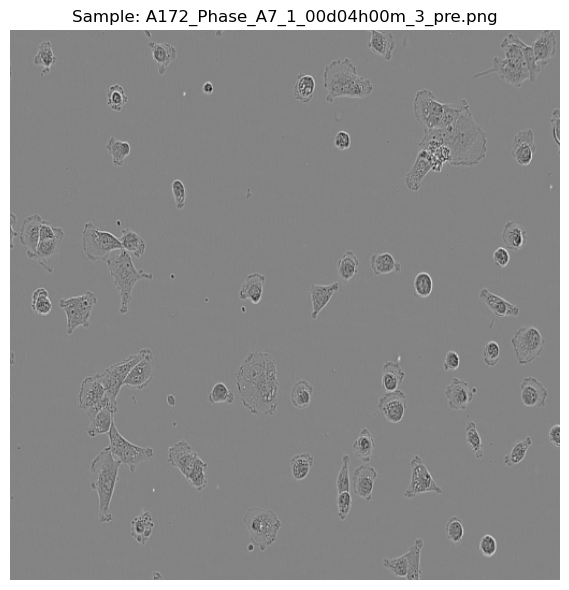

Shape: (512, 512) | Min: 6 | Max: 238


In [3]:
sample_path = PROJECT_ROOT / cfg['paths']['preprocessed_dir'] / preprocessed_log[0]['preprocessed']
sample_img = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 6))
plt.imshow(sample_img, cmap='gray')
plt.title(f"Sample: {preprocessed_log[0]['preprocessed']}")
plt.axis('off')
plt.tight_layout()
plt.show()
print(f"Shape: {sample_img.shape} | Min: {sample_img.min()} | Max: {sample_img.max()}")

---
## Module 2 — Patch Generation
**Input:** Preprocessed images  
**Output:** 9 patches per image (3x3 grid) saved to `data/patches/`  
**Critical:** `patch_manifest.csv` is generated here — required for all downstream splits

In [4]:
# Module 

def run_patch_generation():
    preprocessed_dir = PROJECT_ROOT / cfg['paths']['preprocessed_dir']
    patches_dir      = PROJECT_ROOT / cfg['paths']['patches_dir']
    grid_size        = cfg['patching']['grid_size']

    images = sorted(preprocessed_dir.glob('*.png'))
    if not images:
        print("No preprocessed images found."); return None

    manifest = []

    for img_path in images:
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        h, w = img.shape
        ph, pw = h // grid_size, w // grid_size  # patch height and width

        for row in range(grid_size):
            for col in range(grid_size):
                y1, y2 = row * ph, (row + 1) * ph
                x1, x2 = col * pw, (col + 1) * pw
                patch = img[y1:y2, x1:x2]

                patch_name = f"{img_path.stem}_r{row}c{col}.png"
                cv2.imwrite(str(patches_dir / patch_name), patch)

                manifest.append({
                    'patch_path'  : str(patches_dir / patch_name),
                    'patch_name'  : patch_name,
                    'sample_id'   : img_path.stem,
                    'patch_row'   : row,
                    'patch_col'   : col,
                    'timepoint'   : 'unknown',   # will be assigned next
                    'concentration': None,
                    'label'       : None
                })

    df = pd.DataFrame(manifest)

    # ── Assign timepoint from filename timestamp ──────────────
    # Filenames contain 00d00h00m = day 0 → treat as 'before'
    # Any image with d > 0 or h > 0 → treat as 'after'
    def assign_timepoint(sample_id):
        import re
        match = re.search(r'(\d+)d(\d+)h(\d+)m', sample_id)
        if match:
            d, h, m = int(match.group(1)), int(match.group(2)), int(match.group(3))
            return 'before' if (d == 0 and h == 0) else 'after'
        return 'unknown'

    df['timepoint'] = df['sample_id'].apply(assign_timepoint)

    manifest_path = PROJECT_ROOT / cfg['paths']['patch_manifest']
    df.to_csv(manifest_path, index=False)

    print(f"Patches generated: {len(df)}")
    print(f"Timepoint breakdown:\n{df['timepoint'].value_counts().to_string()}")
    print(f"\nManifest saved to: {manifest_path}")
    return df

patch_manifest = run_patch_generation()

Patches generated: 270
Timepoint breakdown:
timepoint
after     234
before     36

Manifest saved to: /Users/E.M.A./Documents/Claude/Projects/Capstone Project/patch_manifest.csv


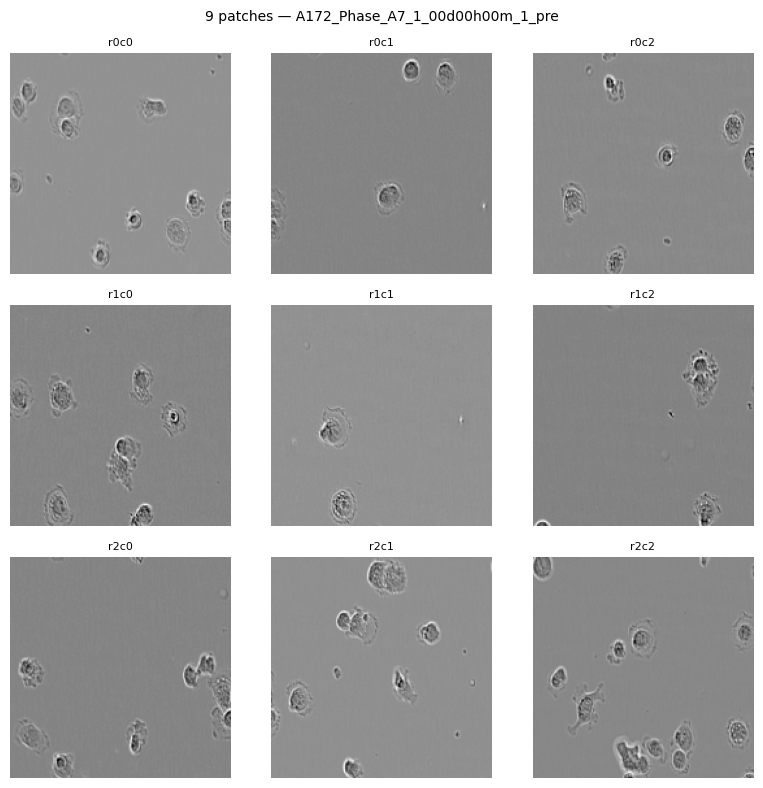

In [5]:
sample_patches = patch_manifest[patch_manifest['sample_id'] == patch_manifest['sample_id'].iloc[0]]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for idx, (_, row) in enumerate(sample_patches.iterrows()):
    r, c = idx // 3, idx % 3
    patch = cv2.imread(row['patch_path'], cv2.IMREAD_GRAYSCALE)
    axes[r, c].imshow(patch, cmap='gray')
    axes[r, c].set_title(f"r{row['patch_row']}c{row['patch_col']}", fontsize=8)
    axes[r, c].axis('off')

plt.suptitle(f"9 patches — {patch_manifest['sample_id'].iloc[0]}", fontsize=10)
plt.tight_layout()
plt.show()

---
## Module 3 — Feature Extraction
**Input:** Patches (from `data/patches/`) + patch manifest  
**Output:** One row of numerical features per patch → `outputs/features/raw_features.csv`  
**Tool:** scikit-image (`regionprops_table` + skeletonization)

In [6]:
# Module 3

from skimage import filters, measure, morphology, exposure
from skimage.morphology import skeletonize
from skimage.feature import canny
from scipy.ndimage import binary_fill_holes

from scipy.ndimage import gaussian_filter
from skimage.segmentation import watershed
from scipy import ndimage as ndi

def segment_patch(img_float):
    """Phase contrast segmentation with watershed to separate touching cells."""
    # Background subtraction
    background = gaussian_filter(img_float, sigma=20)
    deviation  = np.abs(img_float - background)
    thresh     = np.percentile(deviation, 88)
    binary     = deviation > thresh
    binary     = morphology.remove_small_objects(binary, min_size=150)
    binary     = morphology.remove_small_holes(binary, area_threshold=300)

    # Watershed: find cell centers from distance transform peaks
    distance = ndi.distance_transform_edt(binary)
    coords   = morphology.local_maxima(distance, indices=True)
    # Filter peaks that are too close together (min 15px apart)
    from skimage.feature import peak_local_max
    coords   = peak_local_max(distance, min_distance=15, labels=binary)
    mask     = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels   = watershed(-distance, markers, mask=binary)

    return labels > 0

def extract_features(patch_path):
    img = cv2.imread(str(patch_path), cv2.IMREAD_GRAYSCALE)
    img_float = img.astype(np.float32) / 255.0
    binary = segment_patch(img_float)

    labeled = measure.label(binary)
    regions = measure.regionprops(labeled, intensity_image=img_float)
    if not regions:
        return None

    areas          = [r.area for r in regions]
    perimeters     = [r.perimeter for r in regions]
    circularities  = [4 * np.pi * r.area / (r.perimeter ** 2) if r.perimeter > 0 else 0 for r in regions]
    eccentricities = [r.eccentricity for r in regions]
    solidities     = [r.solidity for r in regions]

    skeleton        = skeletonize(binary)
    neurite_length  = int(skeleton.sum())
    from scipy.ndimage import convolve
    kernel          = np.ones((3, 3), dtype=int)
    neighbour_count = convolve(skeleton.astype(int), kernel)
    branch_points   = int(((neighbour_count >= 4) & skeleton).sum())
    total_area      = binary.sum()
    neurite_density = neurite_length / total_area if total_area > 0 else 0

    return {
        'cell_count'       : len(regions),
        'soma_area_mean'   : np.mean(areas),
        'soma_area_total'  : np.sum(areas),
        'perimeter_mean'   : np.mean(perimeters),
        'circularity_mean' : np.mean(circularities),
        'eccentricity_mean': np.mean(eccentricities),
        'solidity_mean'    : np.mean(solidities),
        'neurite_length'   : neurite_length,
        'branch_count'     : branch_points,
        'neurite_density'  : neurite_density,
    }
def run_feature_extraction():
    features_dir = PROJECT_ROOT / cfg['paths']['features_dir']
    rows = []

    print(f"Extracting features from {len(patch_manifest)} patches...\n")

    for _, patch_row in patch_manifest.iterrows():
        feats = extract_features(patch_row['patch_path'])
        if feats is None:
            continue
        row = {
            'sample_id'    : patch_row['sample_id'],
            'patch_name'   : patch_row['patch_name'],
            'patch_row'    : patch_row['patch_row'],
            'patch_col'    : patch_row['patch_col'],
            'timepoint'    : patch_row['timepoint'],
            'concentration': patch_row['concentration'],
            'label'        : patch_row['label'],
        }
        row.update(feats)
        rows.append(row)

    df = pd.DataFrame(rows)
    out_path = features_dir / 'raw_features.csv'
    df.to_csv(out_path, index=False)

    print(f"Features extracted: {len(df)} patches")
    print(f"Features per patch: {len(df.columns)} columns")
    print(f"\nSample output:\n{df.head(3).to_string()}")
    print(f"\nSaved to: {out_path}")
    return df

features_df = run_feature_extraction()

Extracting features from 270 patches...

Features extracted: 264 patches
Features per patch: 17 columns

Sample output:
                         sample_id                                patch_name  patch_row  patch_col timepoint concentration label  cell_count  soma_area_mean  soma_area_total  perimeter_mean  circularity_mean  eccentricity_mean  solidity_mean  neurite_length  branch_count  neurite_density
0  A172_Phase_A7_1_00d00h00m_1_pre  A172_Phase_A7_1_00d00h00m_1_pre_r0c0.png          0          0    before          None  None           7      420.285714           2942.0       99.354618          0.538538           0.750577       0.864761             365            73         0.124065
1  A172_Phase_A7_1_00d00h00m_1_pre  A172_Phase_A7_1_00d00h00m_1_pre_r0c1.png          0          1    before          None  None           3      465.333333           1396.0      100.300180          0.569182           0.662700       0.856033             200            51         0.143266
2  A172_Phase

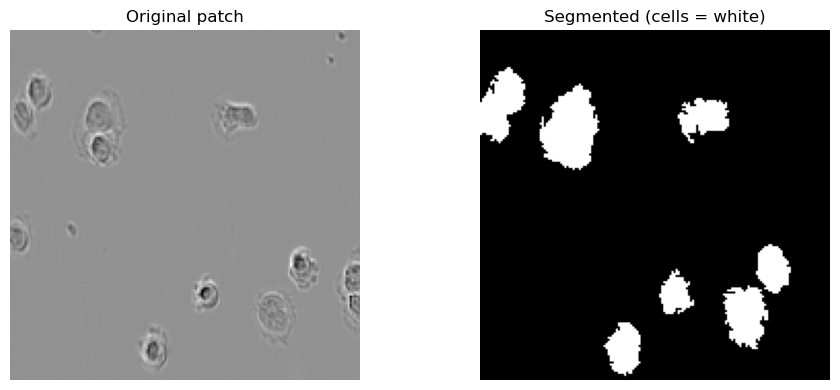

In [7]:
sample_patch_path = patch_manifest['patch_path'].iloc[0]
img = cv2.imread(sample_patch_path, cv2.IMREAD_GRAYSCALE)
img_float = img.astype(np.float32) / 255.0
binary = segment_patch(img_float)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original patch')
axes[0].axis('off')
axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Segmented (cells = white)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

---
## Modules 4a / 4b — Before & After Feature Tables
**Input:** Raw features CSV + timepoint labels from patch manifest  
**Output:** Two separate DataFrames — `before_features` and `after_features`, aligned by sample_id

In [8]:
# Modules 4a / 4b — Separate Before & After Feature Tables

before_df = features_df[features_df['timepoint'] == 'before'].copy()
after_df  = features_df[features_df['timepoint'] == 'after'].copy()

print(f"Before patches : {len(before_df)}")
print(f"After patches  : {len(after_df)}")
print(f"\nBefore samples:\n{before_df['sample_id'].unique()}")
print(f"\nAfter samples:\n{after_df['sample_id'].unique()}")

Before patches : 36
After patches  : 228

Before samples:
['A172_Phase_A7_1_00d00h00m_1_pre' 'A172_Phase_A7_1_00d00h00m_2_pre'
 'A172_Phase_A7_1_00d00h00m_3_pre' 'A172_Phase_A7_1_00d00h00m_4_pre']

After samples:
['A172_Phase_A7_1_00d04h00m_1_pre' 'A172_Phase_A7_1_00d04h00m_2_pre'
 'A172_Phase_A7_1_00d04h00m_3_pre' 'A172_Phase_A7_1_00d04h00m_4_pre'
 'A172_Phase_A7_1_00d08h00m_1_pre' 'A172_Phase_A7_1_00d08h00m_2_pre'
 'A172_Phase_A7_1_00d08h00m_3_pre' 'A172_Phase_A7_1_00d08h00m_4_pre'
 'A172_Phase_A7_1_00d12h00m_1_pre' 'A172_Phase_A7_1_00d12h00m_2_pre'
 'A172_Phase_A7_1_00d12h00m_4_pre' 'A172_Phase_A7_1_00d16h00m_1_pre'
 'A172_Phase_A7_1_00d16h00m_2_pre' 'A172_Phase_A7_1_00d16h00m_3_pre'
 'A172_Phase_A7_1_00d16h00m_4_pre' 'A172_Phase_A7_1_00d20h00m_1_pre'
 'A172_Phase_A7_1_00d20h00m_2_pre' 'A172_Phase_A7_1_00d20h00m_3_pre'
 'A172_Phase_A7_1_00d20h00m_4_pre' 'A172_Phase_A7_1_01d00h00m_1_pre'
 'A172_Phase_A7_1_01d00h00m_2_pre' 'A172_Phase_C7_1_00d12h00m_1_pre'
 'A172_Phase_C7_1_00d12h00m_

---
## Module 5 — Delta Computation
**Input:** Before and after feature tables  
**Output:** Delta columns: `delta_feature = after_value − before_value` for every feature

In [9]:
# Module 5 — Delta Computation

import re

# ── Extract base_id by removing timepoint from sample_id ──────
def get_base_id(sample_id):
    # Removes e.g. _00d04h00m_1_pre  →  leaves well + replicate identifier
    return re.sub(r'_\d+d\d+h\d+m', '', sample_id)

features_df['base_id'] = features_df['sample_id'].apply(get_base_id)

# ── Split into before / after ──────────────────────────────────
before_df = features_df[features_df['timepoint'] == 'before'].copy()
after_df  = features_df[features_df['timepoint'] == 'after'].copy()

print(f"Before patches : {len(before_df)}")
print(f"After patches  : {len(after_df)}")
print(f"Unique base_ids in before : {before_df['base_id'].nunique()}")
print(f"Unique base_ids in after  : {after_df['base_id'].nunique()}")

# ── Feature columns to compute deltas for ─────────────────────
feature_cols = [
    'cell_count', 'soma_area_mean', 'soma_area_total',
    'perimeter_mean', 'circularity_mean', 'eccentricity_mean',
    'solidity_mean', 'neurite_length', 'branch_count', 'neurite_density'
]

# ── Delta computation: one row per (before, after) pair ───────
# Each base_id can have multiple after timepoints (4h, 8h, 20h …).
# We iterate over every before patch, find all after patches that
# share the same base_id + patch position, and emit one delta row
# per pairing — giving us more training samples than a 1-to-1 match.

delta_rows = []

for _, b_row in before_df.iterrows():
    matching = after_df[
        (after_df['base_id']   == b_row['base_id']) &
        (after_df['patch_row'] == b_row['patch_row']) &
        (after_df['patch_col'] == b_row['patch_col'])
    ]
    for _, a_row in matching.iterrows():
        entry = {
            'base_id'         : b_row['base_id'],
            'before_sample_id': b_row['sample_id'],
            'after_sample_id' : a_row['sample_id'],
            'patch_row'       : b_row['patch_row'],
            'patch_col'       : b_row['patch_col'],
        }
        for col in feature_cols:
            entry[f'delta_{col}'] = float(a_row[col]) - float(b_row[col])
        delta_rows.append(entry)

delta_df = pd.DataFrame(delta_rows)

# ── Summary ───────────────────────────────────────────────────
print(f"\nDelta rows computed  : {len(delta_df)}")
print(f"  (= {len(before_df)} before patches × avg {len(delta_df)/len(before_df):.1f} after timepoints each)")
print(f"\nPairing breakdown:")
print(delta_df.groupby(['before_sample_id', 'after_sample_id']).size()
      .rename('patches').reset_index().to_string(index=False))

print(f"\nSample delta rows (first 3):")
display_cols = ['base_id', 'patch_row', 'patch_col',
                'after_sample_id', 'delta_cell_count',
                'delta_neurite_length', 'delta_neurite_density']
print(delta_df[display_cols].head(3).to_string(index=False))

Before patches : 36
After patches  : 228
Unique base_ids in before : 4
Unique base_ids in after  : 8

Delta rows computed  : 187
  (= 36 before patches × avg 5.2 after timepoints each)

Pairing breakdown:
               before_sample_id                 after_sample_id  patches
A172_Phase_A7_1_00d00h00m_1_pre A172_Phase_A7_1_00d04h00m_1_pre        9
A172_Phase_A7_1_00d00h00m_1_pre A172_Phase_A7_1_00d08h00m_1_pre        9
A172_Phase_A7_1_00d00h00m_1_pre A172_Phase_A7_1_00d12h00m_1_pre        9
A172_Phase_A7_1_00d00h00m_1_pre A172_Phase_A7_1_00d16h00m_1_pre        9
A172_Phase_A7_1_00d00h00m_1_pre A172_Phase_A7_1_00d20h00m_1_pre        8
A172_Phase_A7_1_00d00h00m_1_pre A172_Phase_A7_1_01d00h00m_1_pre        9
A172_Phase_A7_1_00d00h00m_2_pre A172_Phase_A7_1_00d04h00m_2_pre        9
A172_Phase_A7_1_00d00h00m_2_pre A172_Phase_A7_1_00d08h00m_2_pre        9
A172_Phase_A7_1_00d00h00m_2_pre A172_Phase_A7_1_00d12h00m_2_pre        9
A172_Phase_A7_1_00d00h00m_2_pre A172_Phase_A7_1_00d16h00m_2_pre  

---
## Module 6 — Tabular Dataset Construction
**Input:** Before features + after features + delta features + concentration + label  
**Output:** Final working DataFrame → `outputs/features/dataset.csv`  
**Schema:** sample_id | patch_id | concentration | before_* | after_* | delta_* | label

In [10]:
# Module 6 — Tabular Dataset Construction

# ── Add prefixed before/after feature columns ─────────────────
before_feat = before_df[['sample_id', 'base_id', 'patch_row', 'patch_col'] + feature_cols].copy()
before_feat = before_feat.rename(columns={col: f'before_{col}' for col in feature_cols})
before_feat = before_feat.rename(columns={'sample_id': 'before_sample_id'})

after_feat = after_df[['sample_id', 'base_id', 'patch_row', 'patch_col'] + feature_cols].copy()
after_feat = after_feat.rename(columns={col: f'after_{col}' for col in feature_cols})
after_feat = after_feat.rename(columns={'sample_id': 'after_sample_id'})

# ── Join before and after features onto delta rows ────────────
dataset = delta_df.merge(
    before_feat,
    on=['before_sample_id', 'base_id', 'patch_row', 'patch_col'],
    how='left'
)
dataset = dataset.merge(
    after_feat,
    on=['after_sample_id', 'base_id', 'patch_row', 'patch_col'],
    how='left'
)

# ── Add metadata columns (filled when real data arrives) ──────
dataset['concentration'] = None   # <-- fill this with real values later
dataset['label']         = None   # <-- same as concentration for regression
dataset['is_synthetic']  = False  # real rows are never synthetic

# ── Reorder into a clean schema ───────────────────────────────
id_cols     = ['base_id', 'before_sample_id', 'after_sample_id', 'patch_row', 'patch_col']
before_cols = [f'before_{col}' for col in feature_cols]
after_cols  = [f'after_{col}'  for col in feature_cols]
delta_cols  = [f'delta_{col}'  for col in feature_cols]
meta_cols   = ['concentration', 'label', 'is_synthetic']

dataset = dataset[id_cols + before_cols + after_cols + delta_cols + meta_cols]

# ── Save ──────────────────────────────────────────────────────
out_path = PROJECT_ROOT / cfg['paths']['features_dir'] / 'dataset.csv'
dataset.to_csv(out_path, index=False)

print(f"Dataset shape  : {dataset.shape}")
print(f"Total columns  : {len(dataset.columns)}")
print(f"\nColumn groups:")
print(f"  ID columns   : {len(id_cols)}   {id_cols}")
print(f"  Before feats : {len(before_cols)}")
print(f"  After feats  : {len(after_cols)}")
print(f"  Delta feats  : {len(delta_cols)}")
print(f"  Meta columns : {len(meta_cols)}   {meta_cols}")
print(f"\nSample rows:")
preview_cols = ['base_id', 'patch_row', 'patch_col',
                'after_sample_id', 'before_neurite_length',
                'after_neurite_length', 'delta_neurite_length', 'label']
print(dataset[preview_cols].head(5).to_string(index=False))
print(f"\nSaved to: {out_path}")

# Preview dataset as formatted table
dataset.style.format(precision=2)

Dataset shape  : (187, 38)
Total columns  : 38

Column groups:
  ID columns   : 5   ['base_id', 'before_sample_id', 'after_sample_id', 'patch_row', 'patch_col']
  Before feats : 10
  After feats  : 10
  Delta feats  : 10
  Meta columns : 3   ['concentration', 'label', 'is_synthetic']

Sample rows:
              base_id  patch_row  patch_col                 after_sample_id  before_neurite_length  after_neurite_length  delta_neurite_length label
A172_Phase_A7_1_1_pre          0          0 A172_Phase_A7_1_00d04h00m_1_pre                    365                   380                  15.0  None
A172_Phase_A7_1_1_pre          0          0 A172_Phase_A7_1_00d08h00m_1_pre                    365                   513                 148.0  None
A172_Phase_A7_1_1_pre          0          0 A172_Phase_A7_1_00d12h00m_1_pre                    365                   255                -110.0  None
A172_Phase_A7_1_1_pre          0          0 A172_Phase_A7_1_00d16h00m_1_pre                    365       

,base_id,before_sample_id,after_sample_id,patch_row,patch_col,before_cell_count,before_soma_area_mean,before_soma_area_total,before_perimeter_mean,before_circularity_mean,before_eccentricity_mean,before_solidity_mean,before_neurite_length,before_branch_count,before_neurite_density,after_cell_count,after_soma_area_mean,after_soma_area_total,after_perimeter_mean,after_circularity_mean,after_eccentricity_mean,after_solidity_mean,after_neurite_length,after_branch_count,after_neurite_density,delta_cell_count,delta_soma_area_mean,delta_soma_area_total,delta_perimeter_mean,delta_circularity_mean,delta_eccentricity_mean,delta_solidity_mean,delta_neurite_length,delta_branch_count,delta_neurite_density,concentration,label,is_synthetic
0,A172_Phase_A7_1_1_pre,A172_Phase_A7_1_00d00h00m_1_pre,A172_Phase_A7_1_00d04h00m_1_pre,0,0,7,420.29,2942.00,99.35,0.54,0.75,0.86,365,73,0.12,5,666.40,3332.00,138.82,0.45,0.73,0.81,380,83,0.11,-2.00,246.11,390.00,39.46,-0.09,-0.02,-0.06,15.00,10.00,-0.01,None,None,False
1,A172_Phase_A7_1_1_pre,A172_Phase_A7_1_00d00h00m_1_pre,A172_Phase_A7_1_00d08h00m_1_pre,0,0,7,420.29,2942.00,99.35,0.54,0.75,0.86,365,73,0.12,3,987.00,2961.00,287.33,0.22,0.76,0.67,513,124,0.17,-4.00,566.71,19.00,187.97,-0.32,0.01,-0.19,148.00,51.00,0.05,None,None,False
2,A172_Phase_A7_1_1_pre,A172_Phase_A7_1_00d00h00m_1_pre,A172_Phase_A7_1_00d12h00m_1_pre,0,0,7,420.29,2942.00,99.35,0.54,0.75,0.86,365,73,0.12,2,522.50,1045.00,191.51,0.17,0.87,0.55,255,70,0.24,-5.00,102.21,-1897.00,92.15,-0.37,0.12,-0.32,-110.00,-3.00,0.12,None,None,False
3,A172_Phase_A7_1_1_pre,A172_Phase_A7_1_00d00h00m_1_pre,A172_Phase_A7_1_00d16h00m_1_pre,0,0,7,420.29,2942.00,99.35,0.54,0.75,0.86,365,73,0.12,3,399.33,1198.00,151.07,0.21,0.79,0.62,290,80,0.24,-4.00,-20.95,-1744.00,51.71,-0.33,0.04,-0.24,-75.00,7.00,0.12,None,None,False
4,A172_Phase_A7_1_1_pre,A172_Phase_A7_1_00d00h00m_1_pre,A172_Phase_A7_1_00d20h00m_1_pre,0,0,7,420.29,2942.00,99.35,0.54,0.75,0.86,365,73,0.12,1,427.00,427.00,116.78,0.39,0.65,0.85,71,11,0.17,-6.00,6.71,-2515.00,17.42,-0.15,-0.10,-0.02,-294.00,-62.00,0.04,None,None,False
5,A172_Phase_A7_1_1_pre,A172_Phase_A7_1_00d00h00m_1_pre,A172_Phase_A7_1_01d00h00m_1_pre,0,0,7,420.29,2942.00,99.35,0.54,0.75,0.86,365,73,0.12,1,206.00,206.00,88.77,0.33,0.79,0.64,49,12,0.24,-6.00,-214.29,-2736.00,-10.59,-0.21,0.04,-0.22,-316.00,-61.00,0.11,None,None,False
6,A172_Phase_A7_1_1_pre,A172_Phase_A7_1_00d00h00m_1_pre,A172_Phase_A7_1_00d04h00m_1_pre,0,1,3,465.33,1396.00,100.30,0.57,0.66,0.86,200,51,0.14,1,877.00,877.00,175.23,0.36,0.62,0.78,172,44,0.20,-2.00,411.67,-519.00,74.93,-0.21,-0.04,-0.08,-28.00,-7.00,0.05,None,None,False
7,A172_Phase_A7_1_1_pre,A172_Phase_A7_1_00d00h00m_1_pre,A172_Phase_A7_1_00d08h00m_1_pre,0,1,3,465.33,1396.00,100.30,0.57,0.66,0.86,200,51,0.14,2,643.00,1286.00,107.20,0.62,0.76,0.87,115,17,0.09,-1.00,177.67,-110.00,6.90,0.05,0.09,0.02,-85.00,-34.00,-0.05,None,None,False
8,A172_Phase_A7_1_1_pre,A172_Phase_A7_1_00d00h00m_1_pre,A172_Phase_A7_1_00d12h00m_1_pre,0,1,3,465.33,1396.00,100.30,0.57,0.66,0.86,200,51,0.14,2,935.00,1870.00,207.42,0.34,0.84,0.79,256,52,0.14,-1.00,469.67,474.00,107.12,-0.23,0.18,-0.07,56.00,1.00,-0.01,None,None,False
9,A172_Phase_A7_1_1_pre,A172_Phase_A7_1_00d00h00m_1_pre,A172_Phase_A7_1_00d16h00m_1_pre,0,1,3,465.33,1396.00,100.30,0.57,0.66,0.86,200,51,0.14,2,1021.00,2042.00,228.27,0.29,0.81,0.75,308,69,0.15,-1.00,555.67,646.00,127.97,-0.28,0.15,-0.11,108.00,18.00,0.01,None,None,False


---
## Module 7 — Tabular Jitter Augmentation
**Input:** Real dataset from Module 6  
**Output:** Expanded dataset with `is_synthetic` column  
**Noise:** `alpha × std(feature)` per column — alpha configured in `config.yaml`  
**Note:** `is_synthetic=True` rows are used for training only, never for evaluation

In [11]:
# Module 7

alpha       = cfg['augmentation']['alpha']
target_rows = cfg['augmentation']['target_rows']
random_seed = cfg['augmentation']['random_seed']
rng         = np.random.default_rng(random_seed)

# ── Columns to augment (all numeric feature columns) ──────────
aug_cols = before_cols + after_cols + delta_cols

# ── Only augment real rows ─────────────────────────────────────
real_df = dataset[dataset['is_synthetic'] == False].copy()

# ── Compute per-column std on real data ───────────────────────
col_stds = real_df[aug_cols].std()

# ── Generate synthetic rows until target is reached ───────────
rows_needed  = target_rows - len(real_df)
synthetic_rows = []

while len(synthetic_rows) < rows_needed:
    # Sample a random real row
    base = real_df.sample(1, random_state=rng.integers(1e6)).iloc[0].copy()
    # Add noise: alpha × std per feature
    for col in aug_cols:
        base[col] += rng.normal(0, alpha * col_stds[col])
    base['is_synthetic'] = True
    synthetic_rows.append(base)

synthetic_df = pd.DataFrame(synthetic_rows)

# ── Combine real + synthetic ───────────────────────────────────
augmented_df = pd.concat([real_df, synthetic_df], ignore_index=True)

# ── Save ──────────────────────────────────────────────────────
out_path = PROJECT_ROOT / cfg['paths']['features_dir'] / 'augmented_dataset.csv'
augmented_df.to_csv(out_path, index=False)

print(f"Real rows      : {len(real_df)}")
print(f"Synthetic rows : {len(synthetic_df)}")
print(f"Total rows     : {len(augmented_df)}")
print(f"\nis_synthetic breakdown:\n{augmented_df['is_synthetic'].value_counts().to_string()}")
print(f"\nSaved to: {out_path}")

Real rows      : 187
Synthetic rows : 6813
Total rows     : 7000

is_synthetic breakdown:
is_synthetic
True     6813
False     187

Saved to: /Users/E.M.A./Documents/Claude/Projects/Capstone Project/outputs/features/augmented_dataset.csv


---
## Module 8 — ML Model Training
**Input:** Augmented training set (real + synthetic) | held-out real test set  
**Models:** XGBRegressor, RandomForestRegressor, SVR  
**CV:** GroupKFold with groups=sample_id  
**Metrics:** RMSE (primary), MAE, R² — evaluated on real data only

###### Module 8 # Module 8 — ML Model Training


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# ── Config ────────────────────────────────────────────────────
SEED      = cfg['ml']['random_seed']
CV_FOLDS  = cfg['ml']['cv_folds']
TEST_SIZE = cfg['ml']['test_size']

# ── Feature columns for ML ────────────────────────────────────
X_cols = before_cols + after_cols + delta_cols

# ── Prototype: label is None → use delta_neurite_length as proxy
# When real data arrives, replace this with actual concentration labels
augmented_df['label'] = augmented_df['delta_neurite_length']

# ── Split: real rows only for test set ────────────────────────
real_data  = augmented_df[augmented_df['is_synthetic'] == False].copy()
synth_data = augmented_df[augmented_df['is_synthetic'] == True].copy()

# Hold out 20% of real rows as test set (never seen during training)
n_test     = max(1, int(len(real_data) * TEST_SIZE))
test_df    = real_data.sample(n=n_test, random_state=SEED)
train_real = real_data.drop(test_df.index)

# Training set = remaining real rows + all synthetic rows
train_df   = pd.concat([train_real, synth_data], ignore_index=True)

# Fix: remove proxy label from input features to avoid data leakage
X_cols_fixed = [c for c in X_cols if c != 'delta_neurite_length']

X_train = train_df[X_cols_fixed].fillna(0).values
y_train = train_df['label'].values
X_test  = test_df[X_cols_fixed].fillna(0).values
y_test  = test_df['label'].values

# ── Scale features (required for SVR) ─────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training rows  : {len(X_train)}  (real: {len(train_real)}, synthetic: {len(synth_data)})")
print(f"Test rows      : {len(X_test)}  (real only)")
print(f"Input features : {len(X_cols_fixed)}")

# ── Define models ─────────────────────────────────────────────
models = {
    'xgboost'       : xgb.XGBRegressor(n_estimators=100, random_state=SEED,
                                        verbosity=0, eval_metric='rmse'),
    'random_forest' : RandomForestRegressor(n_estimators=100, random_state=SEED),
    'svr'           : SVR(kernel='rbf', C=1.0, epsilon=0.1),
}

# ── Train and evaluate ────────────────────────────────────────
results = {}

for name, model in models.items():
    Xtr = X_train_sc if name == 'svr' else X_train
    Xte = X_test_sc  if name == 'svr' else X_test

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    results[name] = {'rmse': rmse, 'mae': mae, 'r2': r2, 'model': model}
    print(f"\n{name.upper()}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")

print("\n── Best model by RMSE ──")
best_name = min(results, key=lambda k: results[k]['rmse'])
print(f"  {best_name}  (RMSE: {results[best_name]['rmse']:.4f})")

---
## Module 9 — Interpretability Output
**Input:** Trained models + real test data  
**Output:** SHAP values (XGBoost, RF) + permutation importance (SVR); ranked feature importance by association with differentiation


── SHAP: XGBOOST — Top 10 features ──
                feature  importance
  delta_soma_area_total   87.959709
     delta_branch_count   63.061287
  after_soma_area_total   16.910503
   after_neurite_length   11.732213
  before_neurite_length    5.762998
 before_neurite_density    5.054580
 delta_circularity_mean    4.089175
   after_soma_area_mean    2.212606
delta_eccentricity_mean    1.957622
     after_branch_count    1.938170


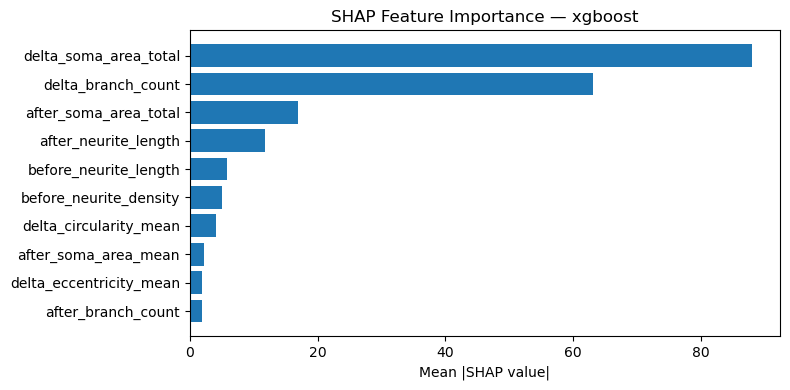


── SHAP: RANDOM_FOREST — Top 10 features ──
                feature  importance
  delta_soma_area_total  100.539724
     delta_branch_count   69.945447
  after_soma_area_total    8.630264
   after_neurite_length    4.308848
    delta_solidity_mean    3.317836
 delta_circularity_mean    3.186422
    before_branch_count    2.704815
 before_neurite_density    2.592710
delta_eccentricity_mean    2.446186
before_circularity_mean    1.939662


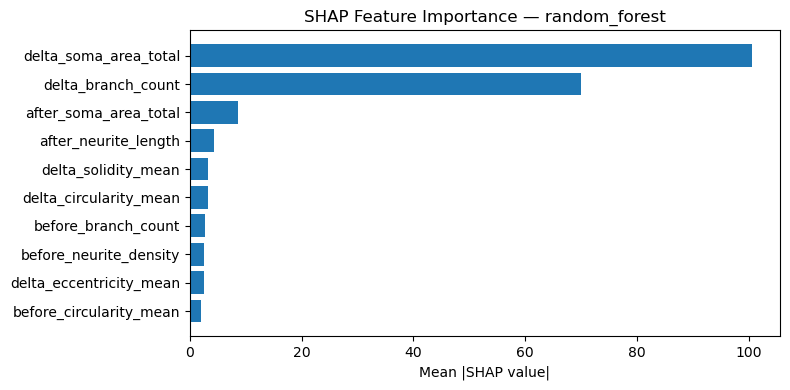


── Permutation Importance: SVR — Top 10 features ──
              feature  importance
 after_neurite_length    0.074059
   delta_branch_count    0.060294
after_soma_area_total    0.051527
delta_soma_area_total    0.050405
   after_branch_count    0.042992
     after_cell_count    0.041622
     delta_cell_count    0.041105
before_neurite_length    0.035289
  before_branch_count    0.030016
 delta_perimeter_mean    0.026597


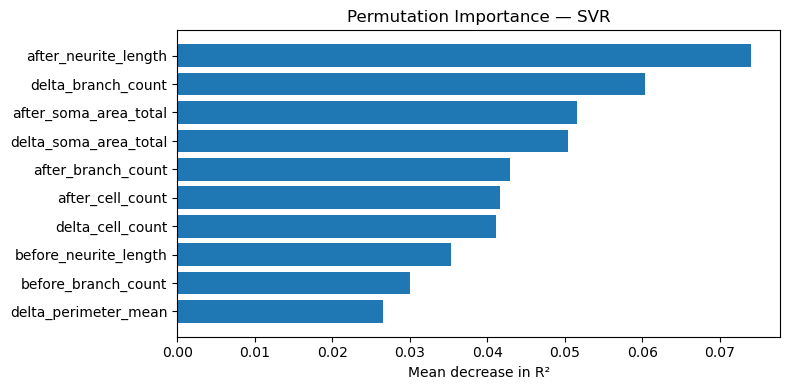


Plots saved to: /Users/E.M.A./Documents/Claude/Projects/Capstone Project/outputs/plots


In [13]:
# Module 9

import shap
from sklearn.inspection import permutation_importance

top_n = cfg['interpretability']['top_n_features']

# ── SHAP — XGBoost & Random Forest ───────────────────────────
for name in cfg['interpretability']['shap_models']:
    model = results[name]['model']
    X_explain = test_df[X_cols_fixed].fillna(0).values

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_explain)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_df = pd.DataFrame({
        'feature'   : X_cols_fixed,
        'importance': mean_abs_shap
    }).sort_values('importance', ascending=False).head(top_n)

    print(f"\n── SHAP: {name.upper()} — Top {top_n} features ──")
    print(shap_df.to_string(index=False))

    plt.figure(figsize=(8, 4))
    plt.barh(shap_df['feature'][::-1], shap_df['importance'][::-1])
    plt.xlabel('Mean |SHAP value|')
    plt.title(f'SHAP Feature Importance — {name}')
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / cfg['paths']['plots_dir'] / f'shap_{name}.png', dpi=150)
    plt.show()

# ── Permutation Importance — SVR ──────────────────────────────
print(f"\n── Permutation Importance: SVR — Top {top_n} features ──")
perm = permutation_importance(
    results['svr']['model'],
    X_test_sc, y_test,
    n_repeats=cfg['interpretability']['n_repeats'],
    random_state=SEED
)

perm_df = pd.DataFrame({
    'feature'   : X_cols_fixed,
    'importance': perm.importances_mean
}).sort_values('importance', ascending=False).head(top_n)

print(perm_df.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(perm_df['feature'][::-1], perm_df['importance'][::-1])
plt.xlabel('Mean decrease in R²')
plt.title('Permutation Importance — SVR')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / cfg['paths']['plots_dir'] / 'permutation_svr.png', dpi=150)
plt.show()

print(f"\nPlots saved to: {PROJECT_ROOT / cfg['paths']['plots_dir']}")